# S9 — Robustness and limitations

This is a reporting-only, post-confirmatory stage. It consumes only persisted summaries from S6, S7 and S8. The confirmatory conclusion remains: UpliftTree minus response-propensity baseline = -0.0088447, 95% CI [-0.0491571, 0.0302486]; there is no confirmatory evidence of an advantage.

The goal is to record what remains stable, what is sensitive, and why the material is not ready for direct deployment. Budgets, scenarios and secondary comparisons are treated as exploration, not independent confirmatory tests.

## Contents

- [Evidence register and decision boundary](#s9-1)

---

In [1]:
from pathlib import Path
import logging
import os
import sys
logging.getLogger("duecredit").setLevel(logging.CRITICAL)
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(parent for parent in PROJECT_ROOT.parents if (parent / "src").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.config import PROJECT_ROOT as CONFIG_PROJECT_ROOT
from src.i18n import make_lang
from src.robustness_reports import (
    build_s9_report, display_s9_report, load_s9_inputs,
    plot_s9_report, save_s9_artifacts,
)
PROJECT_ROOT = CONFIG_PROJECT_ROOT
ARTIFACTS_S9_DIR = PROJECT_ROOT / "artifacts" / "s9"
lang = make_lang('en')


<a id="s9-1"></a>

## Evidence register and decision boundary

The register separates confirmatory S6 evidence from exploratory S7/S8 evidence. The robustness summary counts signs and intervals across each full curve; it does not turn every budget into an independent test or select the largest result. Economics remain illustrative, and the permitted decision is learning and prospective randomized pilot design.

S9 — Robustness and limitations | not ready for direct deployment
Evidence register
             evidence_id stage evidence_class                                          claim  estimate    ci_low  ci_high                    status                                                                                                        interpretation
              S6_primary    S6   Confirmatory      UpliftTree - response-propensity baseline -0.008845 -0.049157 0.030249 No confirmatory advantage                                                   The 95% CI includes zero; the primary hypothesis was not confirmed.
               S7_funnel    S7    Exploratory Heterogeneity and ranking on the visit outcome  0.061529       NaN      NaN          Descriptive only                                            The curve is exploratory and does not replace the confirmatory evaluation.
S7_visit_spend_alignment    S7    Exploratory   Correlation between visit and spend rankings  0.094127       NaN      

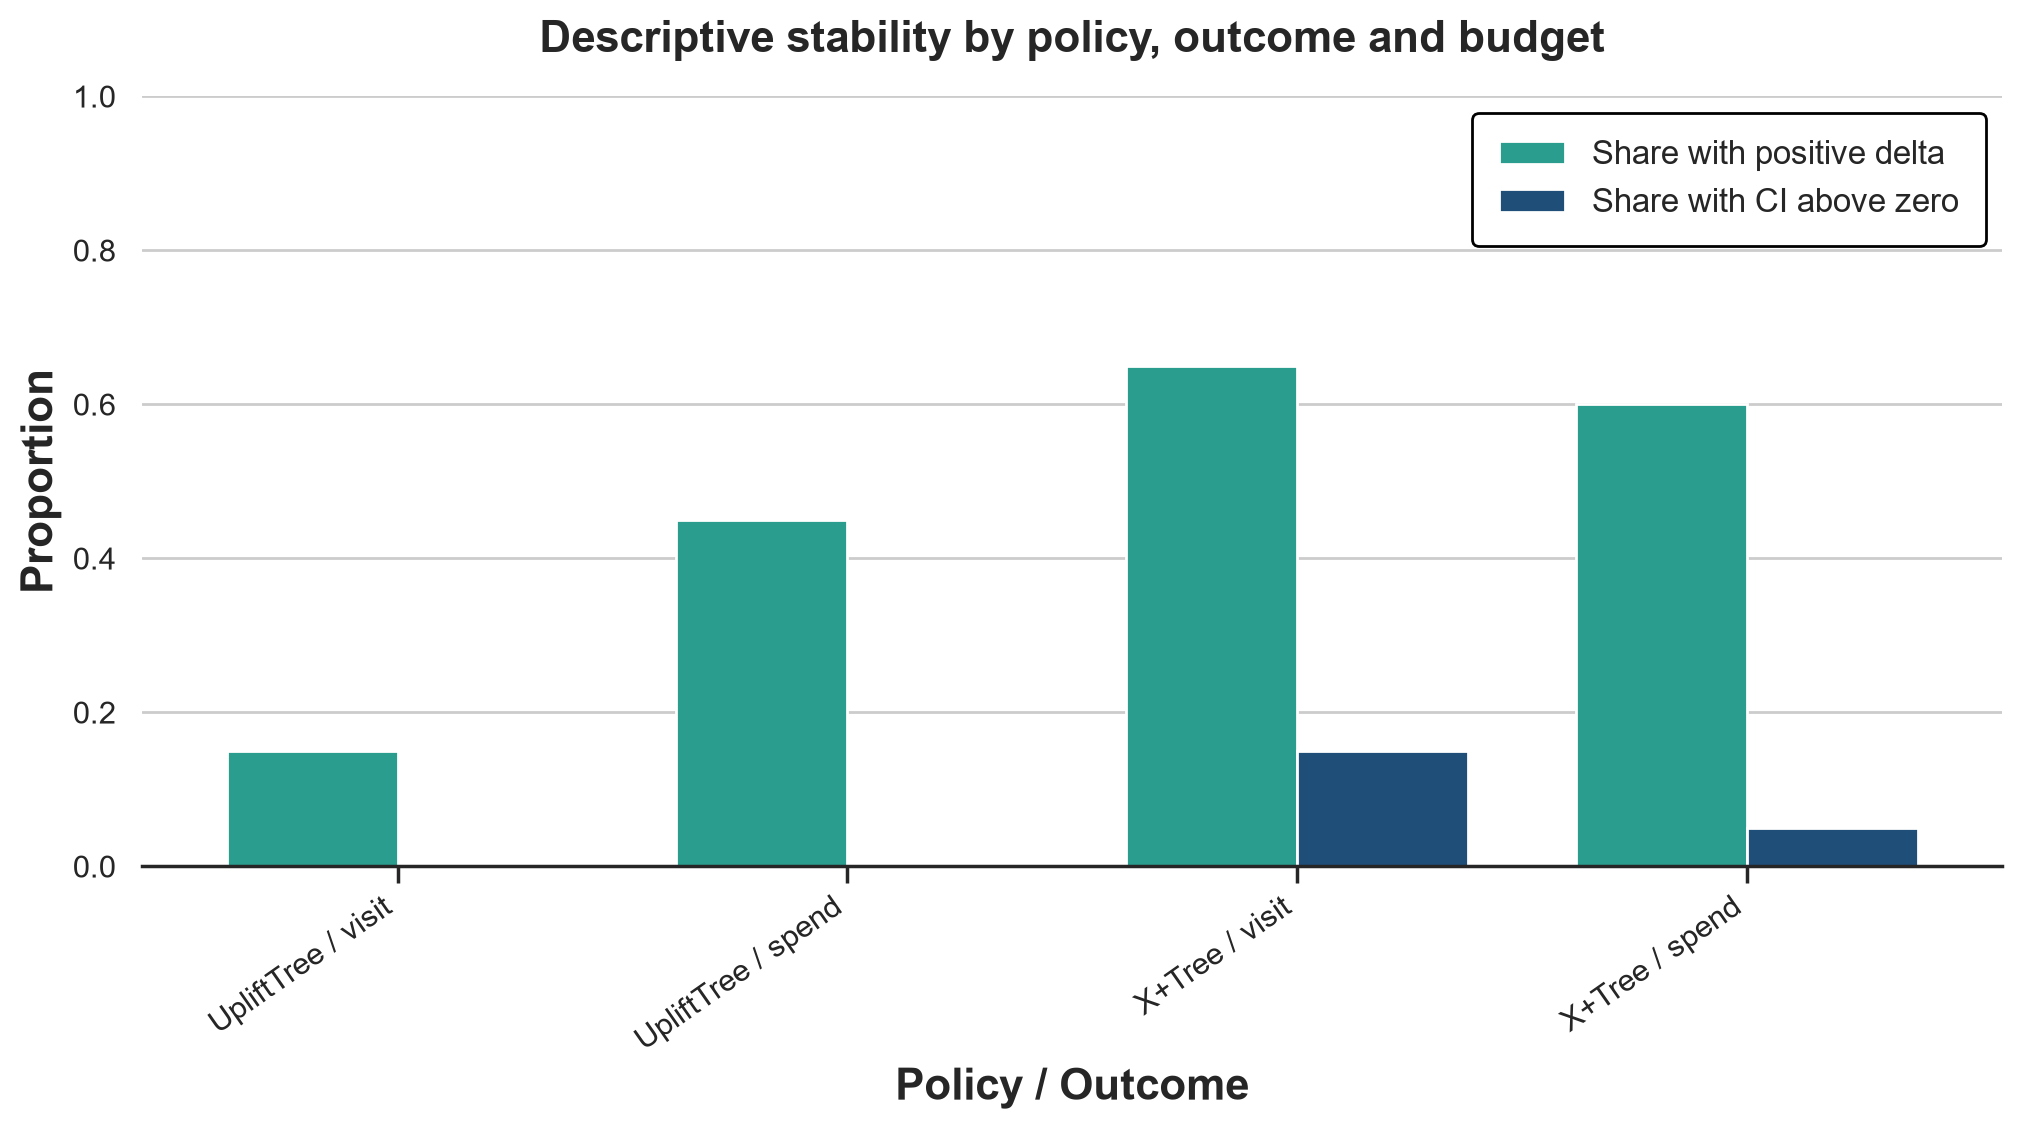

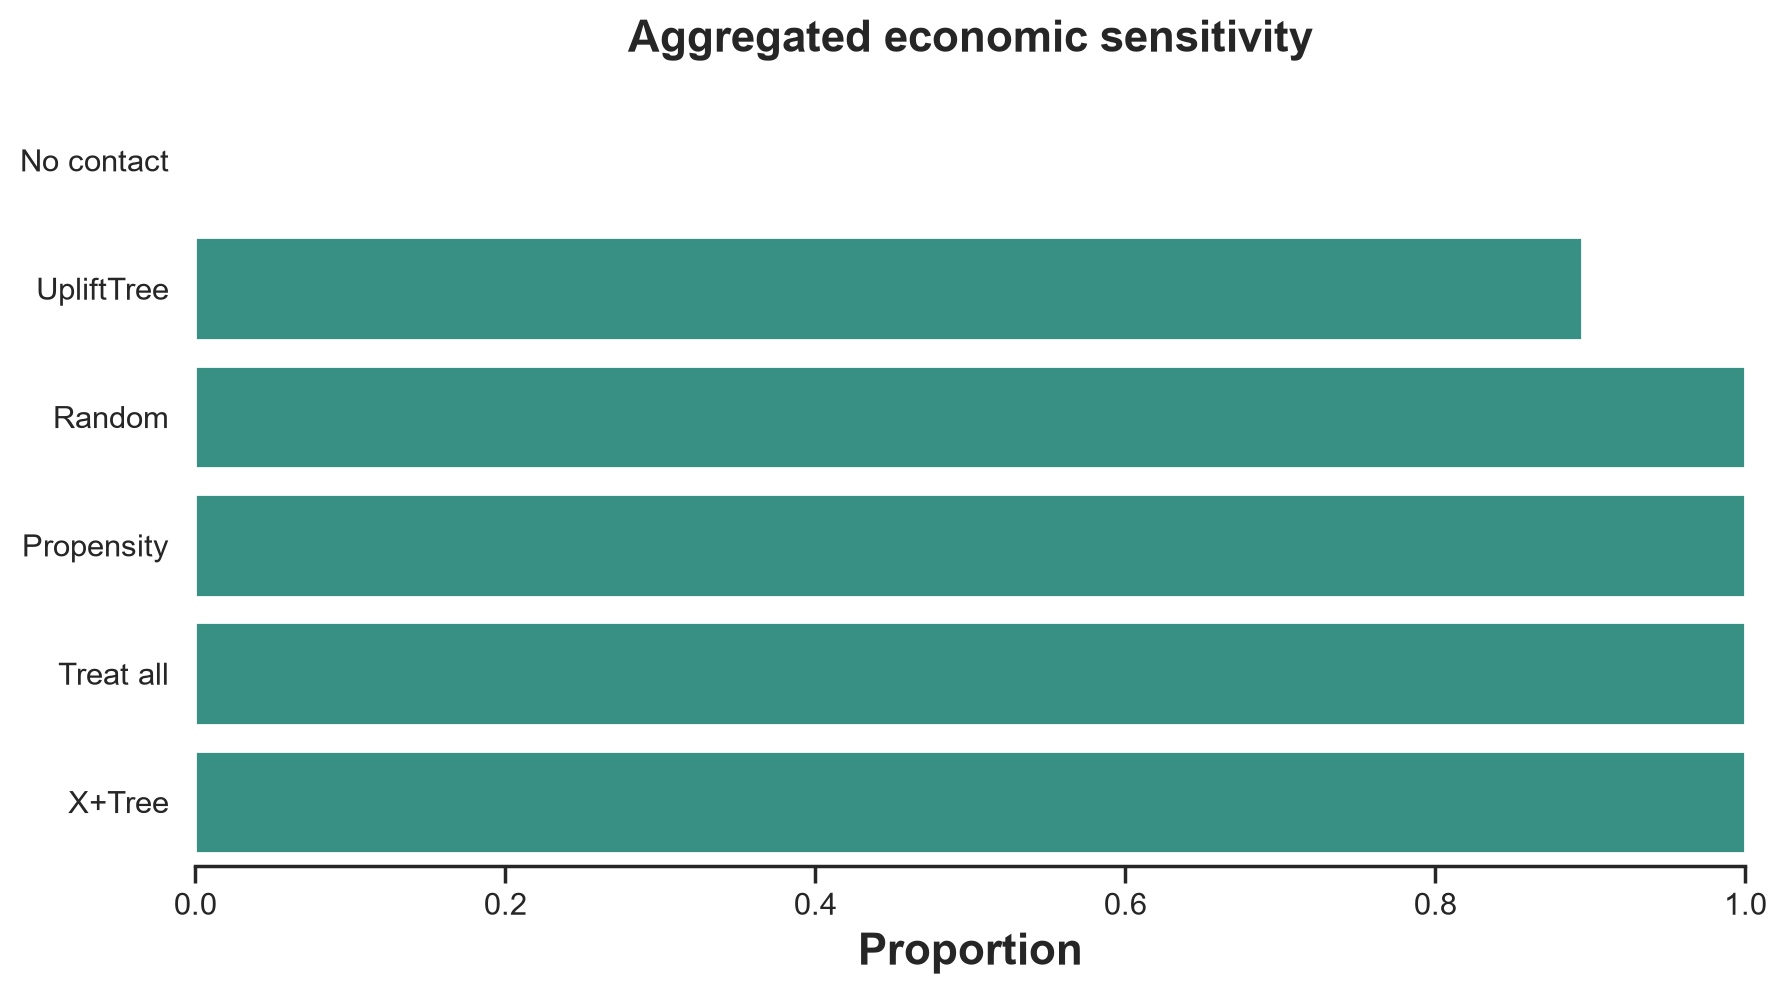

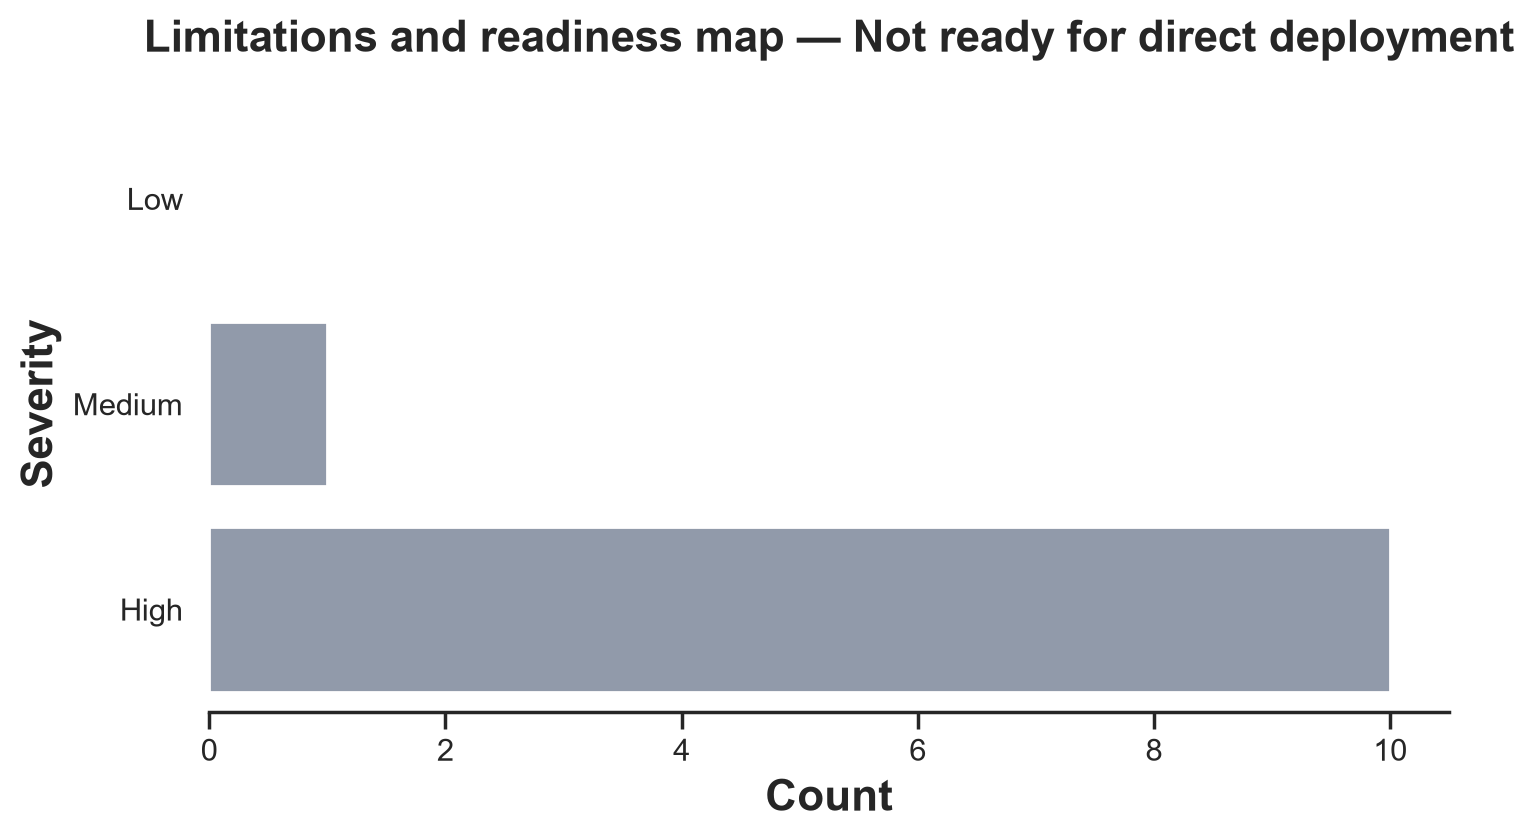

In [2]:
inputs = load_s9_inputs(PROJECT_ROOT / "artifacts")
report = build_s9_report(inputs)
save_s9_artifacts(report, ARTIFACTS_S9_DIR)
display_s9_report(report, lang=lang, artifacts_dir=ARTIFACTS_S9_DIR)
figures = plot_s9_report(report, lang=lang, show=True)
